In [115]:
from ib_insync import *
import random
import asyncio
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

import time
import numpy as np
import matplotlib.pyplot as plt



In [45]:
train_df = pd.read_excel('/Users/thijsmanuel/Documents/cuhk_classes/4130/term_paper/vinci/Data/hsi_vol_train.xlsx').set_index('date')
train_hsi = train_df['2800.HK'] # 21-day realized log volatility of HSI

In [187]:
train_hsi

date
2007-05-02   -3.063372
2007-05-03   -3.114302
2007-05-04   -3.107326
2007-05-07   -3.113554
2007-05-08   -3.125797
                ...   
2021-12-24   -2.834059
2021-12-28   -2.833988
2021-12-29   -2.786126
2021-12-30   -2.776541
2021-12-31   -2.775899
Name: 2800.HK, Length: 3617, dtype: float64

In [47]:
import numpy as np
import torch

def make_dataset(series, seq_len=60):
    data = series.values
    X, Y = [], []

    for t in range(seq_len, len(data)):
        X.append(data[t-seq_len:t])  # past
        Y.append(data[t])            # next step target
    
    X = np.array(X)[:, :, None]  # (samples, seq_len, 1)
    Y = np.array(Y)              # (samples,)
    return X, Y

X, Y = make_dataset(train_hsi, seq_len=1)

In [48]:
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

# Train/test split WITHOUT shuffling (time series!)
split = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:split], X_tensor[split:]
Y_train, Y_test = Y_tensor[:split], Y_tensor[split:]

train_ds = TensorDataset(X_train, Y_train)
test_ds  = TensorDataset(X_test,  Y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DeepVolLSTM(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int = 128,
        num_layers: int = 3,
        dropout: float = 0.3,
        bidirectional: bool = False,
        use_layernorm: bool = True,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        # Deep LSTM stack
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional,
        )

        lstm_out_dim = hidden_dim * self.num_directions

        # Optional normalization on top of LSTM output
        self.use_layernorm = use_layernorm
        if use_layernorm:
            self.ln = nn.LayerNorm(lstm_out_dim)

        # MLP head for volatility mapping
        self.mlp = nn.Sequential(
            nn.Linear(lstm_out_dim, lstm_out_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim // 2, 1),
        )


    def forward(self, x):
        """
        x: (batch_size, seq_len, input_dim)
        returns: (batch_size,) predicted volatility (positive scalar)
        """
        # LSTM forward
        # out: (batch_size, seq_len, hidden_dim * num_directions)
        out, _ = self.lstm(x)

        # Use last time step's hidden state
        last_out = out[:, -1, :]  # (batch_size, hidden_dim * num_directions)

        if self.use_layernorm:
            last_out = self.ln(last_out)

        # MLP head
        vol_raw = self.mlp(last_out)  # (batch_size, 1)

        return vol_raw


In [50]:
input_dim = 1
hidden_dim = 128
num_layers = 3

model = DeepVolLSTM(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    dropout=0.3,
    bidirectional=False,  # you *can* set True, but watch compute
    use_layernorm=True,
)


In [51]:


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()

# Reduce LR by factor 2 when val loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,       # adjust if needed
)

epochs = 100
early_stop_patience = 20
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x_val, y_val in test_loader:
            pred = model(x_val)
            test_loss += loss_fn(pred, y_val).item()
    test_loss /= len(test_loader)

    # LR scheduling based on validation loss
    scheduler.step(test_loss)

    print(f"Epoch {epoch+1:02d} | Train: {train_loss:.4f} | Test: {test_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Early stopping logic
    if test_loss < best_val_loss - 1e-6:
        best_val_loss = test_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= early_stop_patience:
        print(f"\nEarly stopping at epoch {epoch+1}!")
        break


/Users/thijsmanuel/Documents/cuhk_classes/4130/term_paper/vinci/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/Users/thijsmanuel/Documents/cuhk_classes/4130/term_paper/vinci/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([12])) that is different to the input size (torch.Size([12, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/Users/thijsmanuel/Documents/cuhk_classes/4130/term_paper/vinci/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([20])) that is dif

Epoch 01 | Train: 1.0984 | Test: 0.1160 | LR: 0.001000
Epoch 02 | Train: 0.5182 | Test: 0.0815 | LR: 0.001000
Epoch 03 | Train: 0.4240 | Test: 0.0812 | LR: 0.001000
Epoch 04 | Train: 0.4144 | Test: 0.0795 | LR: 0.001000
Epoch 05 | Train: 0.4312 | Test: 0.0818 | LR: 0.001000
Epoch 06 | Train: 0.4417 | Test: 0.0819 | LR: 0.001000
Epoch 07 | Train: 0.4034 | Test: 0.0801 | LR: 0.001000
Epoch 08 | Train: 0.3924 | Test: 0.0799 | LR: 0.001000
Epoch 09 | Train: 0.4228 | Test: 0.0808 | LR: 0.001000
Epoch 10 | Train: 0.3930 | Test: 0.0794 | LR: 0.001000
Epoch 11 | Train: 0.4221 | Test: 0.0808 | LR: 0.001000
Epoch 12 | Train: 0.4325 | Test: 0.0792 | LR: 0.001000
Epoch 13 | Train: 0.4181 | Test: 0.0803 | LR: 0.001000
Epoch 14 | Train: 0.4498 | Test: 0.0820 | LR: 0.001000
Epoch 15 | Train: 0.4194 | Test: 0.0807 | LR: 0.001000
Epoch 16 | Train: 0.4276 | Test: 0.0815 | LR: 0.001000
Epoch 17 | Train: 0.3925 | Test: 0.0851 | LR: 0.001000
Epoch 18 | Train: 0.4209 | Test: 0.0825 | LR: 0.000500
Epoch 19 |

In [167]:
oos_df = pd.read_excel('/Users/thijsmanuel/Documents/cuhk_classes/4130/term_paper/vinci/Data/hsi_vol_oos.xlsx').set_index('date')
oos_hsi = oos_df['2800.HK'] # 21-day realized log volatility of HSI

In [120]:
oos_X, oos_Y = make_dataset(oos_hsi, seq_len=1)

In [56]:
# Convert to tensors
X_oos = torch.tensor(oos_X, dtype=torch.float32)
Y_oos = torch.tensor(oos_Y, dtype=torch.float32)

# Entire out-of-sample dataset is test set
test_ds = TensorDataset(X_oos, Y_oos)

# No training loader needed here
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

In [57]:
model.load_state_dict(best_model_state)

<All keys matched successfully>

In [182]:
oos_df['yesterday'] = oos_df['2800.HK'].shift(1).dropna()

In [184]:
oos_df.dropna()

,2800.HK,yesterday
date,,
2022-01-04,-2.677390,-2.677371
2022-01-05,-2.699221,-2.677390
2022-01-06,-2.665381,-2.699221
2022-01-07,-2.697992,-2.665381
2022-01-10,-2.707104,-2.697992
...,...,...
2025-11-03,-2.960550,-2.950428
2025-11-04,-2.945936,-2.960550
2025-11-05,-2.933204,-2.945936


In [185]:
predicitons = []
for input in oos_hsi['yesterday'].dropna():
    print(input)
    input = torch.tensor(input, dtype=torch.float32).view(1,1,1) # (1, seq_len, 1)
    print('INPUT:',input)
    print('PRED:',model(input).item())
    predicitons.append(model(input).item())
    

-2.677371049135569
INPUT: tensor([[[-2.6774]]])
PRED: -2.7304835319519043
-2.677390347700695
INPUT: tensor([[[-2.6774]]])
PRED: -2.7304999828338623
-2.699221036612564
INPUT: tensor([[[-2.6992]]])
PRED: -2.7492220401763916
-2.665381422430695
INPUT: tensor([[[-2.6654]]])
PRED: -2.7201287746429443
-2.697992390161802
INPUT: tensor([[[-2.6980]]])
PRED: -2.7481725215911865
-2.707103801487149
INPUT: tensor([[[-2.7071]]])
PRED: -2.7559382915496826
-2.687660441625027
INPUT: tensor([[[-2.6877]]])
PRED: -2.7393290996551514
-2.759675494884642
INPUT: tensor([[[-2.7597]]])
PRED: -2.800110101699829
-2.734421738998116
INPUT: tensor([[[-2.7344]]])
PRED: -2.7790305614471436
-2.73357760168419
INPUT: tensor([[[-2.7336]]])
PRED: -2.7783210277557373
-2.703651237303451
INPUT: tensor([[[-2.7037]]])
PRED: -2.7529995441436768
-2.701516168275581
INPUT: tensor([[[-2.7015]]])
PRED: -2.7511799335479736
-2.614992336030064
INPUT: tensor([[[-2.6150]]])
PRED: -2.6760849952697754
-2.745417396841394
INPUT: tensor([[[-2.7

In [148]:
x_input

tensor([[[-2.9480]]])

In [131]:
model.eval()

preds = []
true_vals = []

with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        y_pred = model(X_batch)

        preds.append(y_pred.cpu().numpy())
        true_vals.append(Y_batch.cpu().numpy())

import numpy as np
preds = np.concatenate(preds, axis=0)      # correct axis
true_vals = np.concatenate(true_vals, axis=0)

In [186]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


mse = mean_squared_error(true_vals, predicitons[:-1])
mae = mean_absolute_error(true_vals, predicitons[:-1])
r2 = r2_score(true_vals, predicitons[1:])
print("MSE:", round(mse,3))
print("MAE:", round(mae,3))
print("R2:", round(r2,3))

MSE: 0.008
MAE: 0.064
R2: 0.965


In [76]:
ann_pred = np.exp(preds) * np.sqrt(12) * 100

ann_true = np.exp(true_vals) * np.sqrt(12) * 100

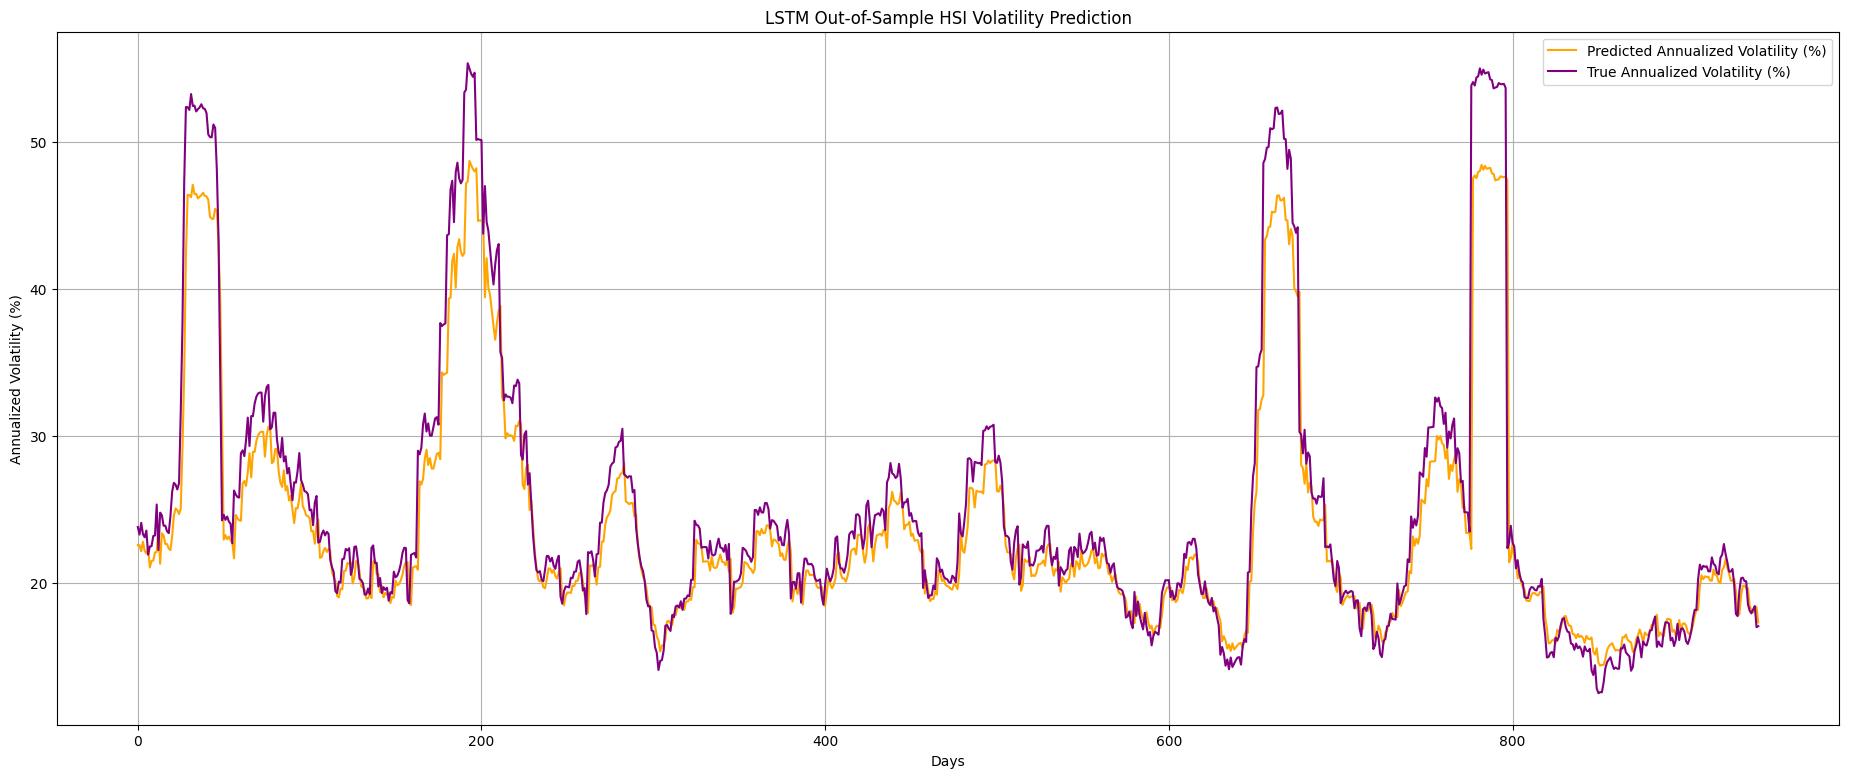

In [119]:
plt.figure(figsize=(23,9))

plt.plot(ann_pred, label='Predicted Annualized Volatility (%)', c='orange')
plt.plot(ann_true, label='True Annualized Volatility (%)', c='purple')
plt.title('LSTM Out-of-Sample HSI Volatility Prediction')
plt.xlabel('Days')
plt.ylabel('Annualized Volatility (%)')
plt.legend()
plt.grid()

In [105]:
residuals = ann_true - ann_pred[:,0]

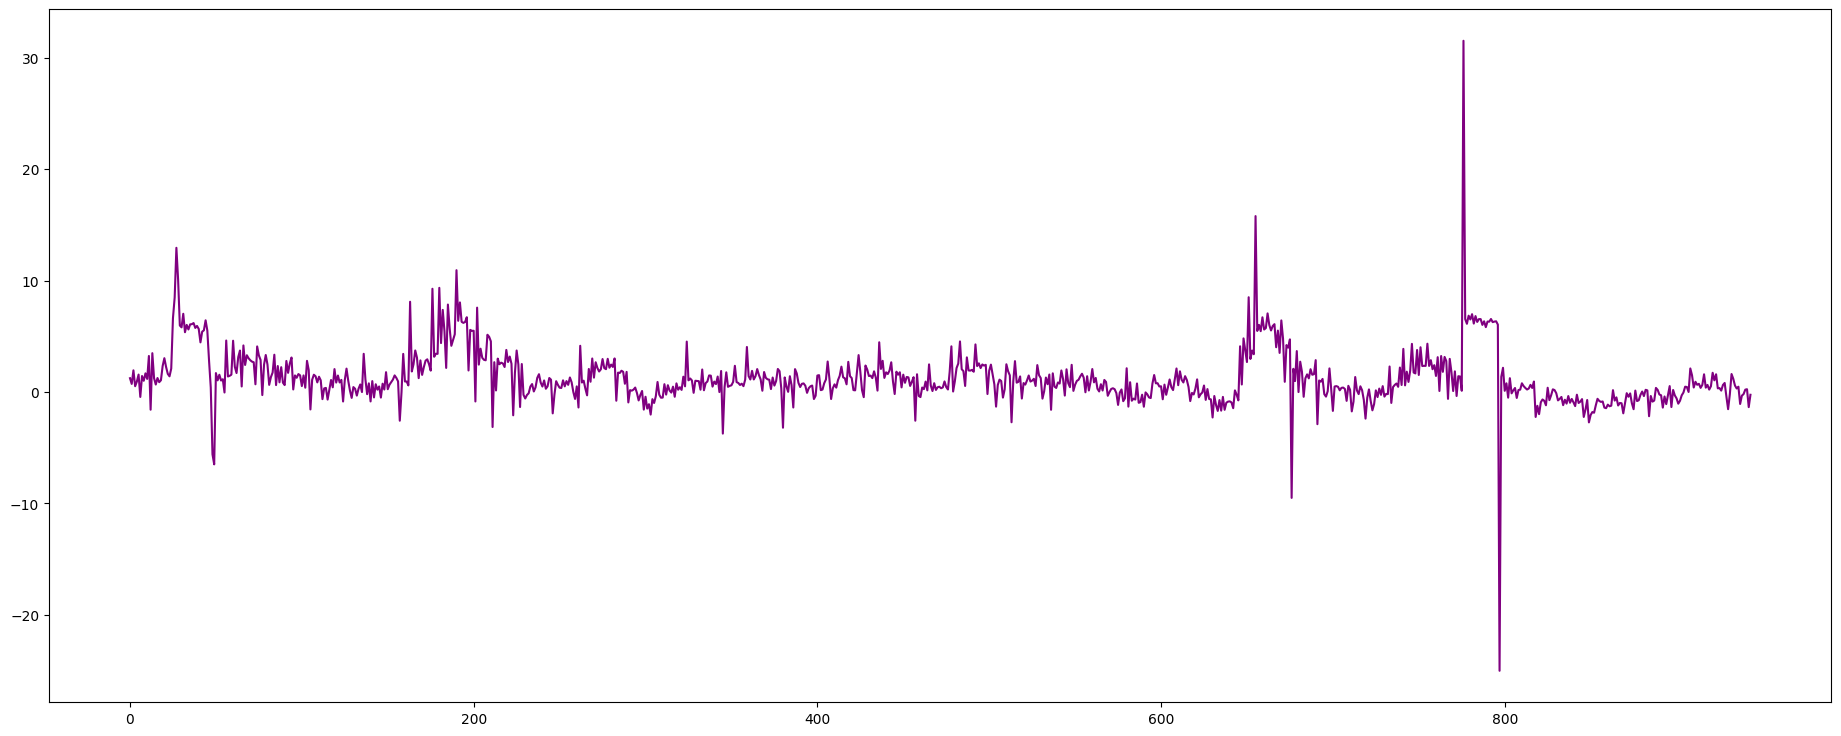

In [117]:
plt.figure(figsize=(23,9))
plt.plot(residuals, label='Residuals', color='purple')

In [111]:
np.save("LSTM_oos_preds.npy", preds)